In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path 
import re

In [2]:
BASE_ROOT = Path.home() / "Escritorio" / "Proyecto_FAERS" 
quarters = [ 
    "Q1/data_processed/q1_2025_sample100k", 
    "Q2/data_processed/q2_2025_sample100k", 
    "Q3/data_processed/q3_2025_sample100k", 
    "Q4/data_processed/q4_2025_sample100k"
]

DEBUG = False # Variable para activar o desactivar mensajes de impresión de diagnóstico

def find_one_csv(qdir: Path, pattern_list): # Define función para buscar un archivo CSV específico
    for pat in pattern_list: # Itera sobre cada patrón de búsqueda en la lista
        hits = list(qdir.glob(pat)) # Busca archivos en el directorio que coincidan con el patrón actual
        if hits: # Si encuentra al menos un archivo que coincida
            return hits[0] # Devuelve el primer archivo encontrado
    return None # Si no encuentra nada, devuelve None

def read_csv_robust(fp: Path): # Define función para leer CSV evitando problemas de formato
    # utf-8-sig elimina BOM si existe
    return pd.read_csv(fp, low_memory=False, encoding="utf-8-sig") # Lee el CSV optimizando memoria y con codificación segura

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame: # Función para normalizar los nombres de columnas
    df = df.copy() # Crea una copia del DataFrame para no modificar el original directamente
    df.columns = ( # Asigna los nuevos nombres de columnas procesados
        pd.Index(df.columns) # Toma los nombres de las columnas actuales
        .map(lambda c: str(c).replace("\ufeff", "").strip().lower()) # Pasa a texto, quita caracteres raros, espacios extra y pone en minúsculas
    ) 
    return df # Devuelve el DataFrame con las columnas limpias

def clean_text_key(s: pd.Series) -> pd.Series: # Función para limpiar el texto de las columnas clave
    # normalización ligera para llaves de texto
    s = s.astype(str).str.upper().str.strip() # Convierte a texto, pone en mayúsculas y quita espacios a los lados
    s = s.str.replace(r"\s+", " ", regex=True) # Reemplaza múltiples espacios en blanco por un solo espacio
    s = s.str.replace(r"[^A-Z0-9 /+\-().,]", "", regex=True) # Elimina caracteres especiales dejando solo lo permitido
    s = s.replace({"NAN": np.nan, "NONE": np.nan, "": np.nan}) # Convierte textos vacíos en verdaderos valores nulos (NaN)
    return s # Devuelve la serie limpia

all_pairs = [] # Lista vacía para ir guardando los datos combinados de medicamentos y reacciones
all_reports = [] # Lista vacía para ir guardando los reportes de cada trimestre

for q in quarters: # Inicia un ciclo que pasará por cada ruta de trimestre definida en tu lista
    qdir = BASE_ROOT / q # Une la ruta del Escritorio con la ruta específica del trimestre
    
    fp_drugs = find_one_csv(qdir, ["*drugs*.csv"]) # Busca el archivo de medicamentos en esa ruta
    fp_reac  = find_one_csv(qdir, ["*reactions*.csv"]) # Busca el archivo de reacciones en esa ruta
    fp_rep   = find_one_csv(qdir, ["*reports*.csv"]) # Busca el archivo de reportes en esa ruta

    if not (fp_drugs and fp_reac and fp_rep): # Comprueba si falta alguno de los tres archivos necesarios
        print(f"[WARN] Faltan archivos en {qdir}") # Imprime advertencia indicando en qué carpeta faltan datos
        print("drugs:", fp_drugs) # Muestra qué encontró para medicamentos
        print("reactions:", fp_reac) # Muestra qué encontró para reacciones
        print("reports:", fp_rep) # Muestra qué encontró para reportes
        continue # Salta al siguiente trimestre si faltan archivos

    print(f"\n=== {q} ===") # Imprime la ruta del trimestre actual como encabezado
    print("drugs     :", fp_drugs.name) # Imprime el nombre exacto del archivo de medicamentos
    print("reactions :", fp_reac.name) # Imprime el nombre exacto del archivo de reacciones
    print("reports   :", fp_rep.name) # Imprime el nombre exacto del archivo de reportes

    # CSV
    d = read_csv_robust(fp_drugs) # Lee el archivo de medicamentos y lo guarda en 'd'
    r = read_csv_robust(fp_reac) # Lee el archivo de reacciones y lo guarda en 'r'
    rep = read_csv_robust(fp_rep) # Lee el archivo de reportes y lo guarda en 'rep'
    
    # Normalizar nombres de columnas
    d = normalize_columns(d) # Limpia los nombres de las columnas en medicamentos
    r = normalize_columns(r) # Limpia los nombres de las columnas en reacciones
    rep = normalize_columns(rep) # Limpia los nombres de las columnas en reportes
    
    if DEBUG: # Si el modo de depuración está activado
        print("drugs cols:", list(d.columns)) # Imprime la lista de columnas de medicamentos
        print("reac  cols:", list(r.columns)) # Imprime la lista de columnas de reacciones
        print("rep   cols:", list(rep.columns)) # Imprime la lista de columnas de reportes
        
    # Validar columnas mínimas
    if "safetyreportid" not in d.columns: # Revisa si falta la columna identificadora en medicamentos
        raise ValueError(f"{q}: drugs no tiene 'safetyreportid'") # Detiene la ejecución con un error si falta
    if "safetyreportid" not in r.columns: # Revisa si falta la columna identificadora en reacciones
        raise ValueError(f"{q}: reactions no tiene 'safetyreportid'") # Detiene la ejecución con un error si falta
    if "reaction_pt" not in r.columns: # Revisa si falta la columna de la reacción
        raise ValueError(f"{q}: reactions no tiene 'reaction_pt'") # Detiene la ejecución con un error si falta
    if "safetyreportid" not in rep.columns: # Revisa si falta la columna identificadora en reportes
        raise ValueError(f"{q}: reports no tiene 'safetyreportid'") # Detiene la ejecución con un error si falta
        
    # Crear drug_key si no existe
    if "drug_key" not in d.columns: # Si la columna estandarizada 'drug_key' no existe
        if "activesubstancename" in d.columns: # Verifica si existe la columna de sustancia activa
            d["drug_key"] = clean_text_key(d["activesubstancename"]) # Crea 'drug_key' limpiando la sustancia activa
            source_used = "activesubstancename" # Registra que usó esta columna
        elif "medicinalproduct" in d.columns: # Si no, verifica si está el nombre comercial
            d["drug_key"] = clean_text_key(d["medicinalproduct"]) # Crea 'drug_key' limpiando el nombre comercial
            source_used = "medicinalproduct" # Registra que usó esta columna
        else: # Si no encuentra ninguna
            raise ValueError( # Lanza un error
                f"{q}: drugs no tiene 'drug_key' ni columnas para construirlo " # Explica el motivo
                f"(activesubstancename/medicinalproduct)." # Menciona qué esperaba
            ) 
        print(f"[INFO] {q}: drug_key construido desde '{source_used}'") # Imprime aviso de qué columna se usó
    else: # Si 'drug_key' ya existía
        d["drug_key"] = clean_text_key(d["drug_key"]) # Aplica la limpieza de texto por precaución

    # Limpieza reaction_pt
    r["reaction_pt"] = clean_text_key(r["reaction_pt"]) # Aplica la limpieza a los nombres de las reacciones

    # Mantener columnas útiles
    keep_d = ["safetyreportid", "drug_key"] # Inicia lista de columnas a conservar en medicamentos
    for c in ["drugcharacterization", "medicinalproduct", "activesubstancename"]: # Revisa otras columnas útiles
        if c in d.columns: # Si existen
            keep_d.append(c) # Las añade a la lista
    d = d[keep_d].copy() # Filtra la tabla dejando solo lo seleccionado

    keep_r = ["safetyreportid", "reaction_pt"] # Inicia lista de columnas a conservar en reacciones
    if "reaction_meddra_version_pt" in r.columns: # Verifica si existe la versión de MedDRA
        keep_r.append("reaction_meddra_version_pt") # La añade a la lista
    r = r[keep_r].copy() # Filtra la tabla dejando solo lo seleccionado
    
    keep_rep = ["safetyreportid"] # Inicia lista de columnas a conservar en reportes
    for c in ["occurcountry", "receiptdate"]: # Revisa columnas de metadatos
        if c in rep.columns: # Si existen
            keep_rep.append(c) # Las añade a la lista
    rep = rep[keep_rep].copy() # Filtra la tabla dejando solo lo seleccionado

    # Tipos
    for x in [d, r, rep]: # Recorre las tres tablas
        x["safetyreportid"] = pd.to_numeric(x["safetyreportid"], errors="coerce") # Fuerza el ID a ser numérico
        x.dropna(subset=["safetyreportid"], inplace=True) # Elimina filas sin un ID válido

    if "drugcharacterization" in d.columns: # Si existe caracterización del medicamento
        d["drugcharacterization"] = pd.to_numeric(d["drugcharacterization"], errors="coerce") # La convierte a número
        
    # Quitar vacíos en llaves
    d = d.dropna(subset=["drug_key"]) # Elimina filas sin nombre del fármaco
    r = r.dropna(subset=["reaction_pt"]) # Elimina filas sin reporte del efecto adverso

    # Deduplicar bases antes del merge
    d = d.drop_duplicates() # Borra filas idénticas en medicamentos
    r = r.drop_duplicates() # Borra filas idénticas en reacciones
    rep = rep.drop_duplicates(subset=["safetyreportid"]) # Asegura un solo reporte por ID

    # Merge drugs x reactions por safetyreportid (genera pares)
    pairs_q = d.merge(r, on="safetyreportid", how="inner", validate="m:m") # Cruza medicamentos y reacciones por ID
    pairs_q["quarter"] = q # Añade la ruta del trimestre como identificador en la columna 'quarter'

    # Enriquecer con reports 
    pairs_q = pairs_q.merge(rep, on="safetyreportid", how="left", validate="m:1") # Pega los datos del reporte por ID

    all_pairs.append(pairs_q) # Guarda el cruce de este trimestre en la lista principal
    all_reports.append(rep.assign(quarter=q)) # Guarda los reportes con su identificador de trimestre

    print("pairs_q shape:", pairs_q.shape) # Imprime dimensiones de los cruces actuales
    print("reports_q shape:", rep.shape) # Imprime dimensiones de los reportes actuales
    print("drug_key nulos:", pairs_q["drug_key"].isna().sum(), "| reaction_pt nulos:", pairs_q["reaction_pt"].isna().sum()) # Confirma ceros nulos

if not all_pairs: # Revisa si no se procesó ningún dato
    raise ValueError("No se pudo construir ningún trimestre.") # Lanza error si falló todo

pairs = pd.concat(all_pairs, ignore_index=True) # Une todas las tablas de pares en un DataFrame final
reports_all = pd.concat(all_reports, ignore_index=True) # Une todos los reportes en un DataFrame final

# Orden de trimestre garantizado
pairs["quarter"] = pd.Categorical(pairs["quarter"], categories=quarters, ordered=True) # Fuerza el orden lógico de los trimestres
reports_all["quarter"] = pd.Categorical(reports_all["quarter"], categories=quarters, ordered=True) # Fuerza el orden lógico en reportes

print("\n=== TOTAL ===") # Imprime encabezado final
print("pairs shape:", pairs.shape) # Muestra el total de filas y columnas final
print("columns:", list(pairs.columns)) # Muestra las columnas finales
print("quarters:\n", pairs["quarter"].value_counts(dropna=False)) # Desglosa filas por trimestre


=== Q1/data_processed/q1_2025_sample100k ===
drugs     : q1_drugs_100k.csv
reactions : q1_reactions_100k.csv
reports   : q1_reports_100k.csv
[INFO] Q1/data_processed/q1_2025_sample100k: drug_key construido desde 'activesubstancename'
pairs_q shape: (2994020, 10)
reports_q shape: (100000, 3)
drug_key nulos: 0 | reaction_pt nulos: 0

=== Q2/data_processed/q2_2025_sample100k ===
drugs     : q2_drugs_100k.csv
reactions : q2_reactions_100k.csv
reports   : q2_reports_100k.csv
[INFO] Q2/data_processed/q2_2025_sample100k: drug_key construido desde 'activesubstancename'
pairs_q shape: (2469562, 10)
reports_q shape: (100000, 3)
drug_key nulos: 0 | reaction_pt nulos: 0

=== Q3/data_processed/q3_2025_sample100k ===
drugs     : q3_drugs_100k.csv
reactions : q3_reactions_100k.csv
reports   : q3_reports_100k.csv
[INFO] Q3/data_processed/q3_2025_sample100k: drug_key construido desde 'activesubstancename'
pairs_q shape: (3051509, 10)
reports_q shape: (100000, 3)
drug_key nulos: 0 | reaction_pt nulos: 

In [3]:
#MAPEO POR OL DE FÁRMACO

In [4]:
# Mapeo de roles FAERS: 1=PS, 2=SS, 3=C, 4=I, 5=O
role_map = {1: "PS", 2: "SS", 3: "C", 4: "I", 5: "O"} 

pairs["drugcharacterization"] = pd.to_numeric(pairs["drugcharacterization"], errors="coerce") #convierte a número o NaN
pairs["role_cod"] = pairs["drugcharacterization"].map(role_map).fillna("UNK") #mapea el rol y llena nulos con "UNK"

print("Distribución de roles (filas):") 
print(pairs["role_cod"].value_counts(dropna=False).rename_axis("role_cod").reset_index(name="n")) #centa filas por cada rol

print("\nReportes únicos por rol (safetyreportid):") 
print(pairs.groupby("role_cod")["safetyreportid"].nunique().sort_values(ascending=False).rename("n_reports").reset_index()) #reportes únicos por rol

# Esquemas
pairs_ps = pairs.loc[pairs["role_cod"].eq("PS")].copy() #filtra solo sospechosos principales (PS)
pairs_ps_ss = pairs.loc[pairs["role_cod"].isin(["PS", "SS"])].copy() #filtra sospechosos principales y secundarios (SS)
pairs_all = pairs.copy() # Copia de todos los datos

print("\n=== Tamaños por esquema (filas) ===") 
print("PS    :", len(pairs_ps)) #total de filas PS
print("PS+SS :", len(pairs_ps_ss))
print("ALL   :", len(pairs_all)) #Total de filas en general

print("\n=== Reportes únicos por esquema ===") 
print("PS    :", pairs_ps["safetyreportid"].nunique()) # Reportes únicos en PS
print("PS+SS :", pairs_ps_ss["safetyreportid"].nunique()) #únicos en PS+SS
print("ALL   :", pairs_all["safetyreportid"].nunique()) # Reportes únicos totales

# Definir esquema principal para estabilidad temporal 
pairs_main = pairs_ps # Define a PS como los datos principales a usar
MAIN_SCHEME = "PS" #Guarda el nombre del esquema
print("\nEsquema principal para estabilidad temporal:", MAIN_SCHEME) 

Distribución de roles (filas):
  role_cod        n
0       PS  6388933
1       SS  5128646
2        C    53255
3        I      121
4      UNK        5

Reportes únicos por rol (safetyreportid):
  role_cod  n_reports
0       PS     388573
1       SS     104362
2        C       2295
3        I         33
4      UNK          1

=== Tamaños por esquema (filas) ===
PS    : 6388933
PS+SS : 11517579
ALL   : 11570960

=== Reportes únicos por esquema ===
PS    : 388573
PS+SS : 389231
ALL   : 390140

Esquema principal para estabilidad temporal: PS


In [5]:
#Separación

In [6]:
admin_patterns = [
    "OFF LABEL USE",
    "DRUG INEFFECTIVE",
    "PRODUCT USE IN UNAPPROVED INDICATION",
    "PRODUCT USE ISSUE",
    "INTENTIONAL PRODUCT USE ISSUE",
    "PRODUCT USE COMPLAINT",
    "DRUG INEFFECTIVE FOR UNAPPROVED INDICATION",
    "THERAPEUTIC PRODUCT EFFECT INCOMPLETE",
    "THERAPEUTIC PRODUCT EFFECT DECREASED",
    "THERAPEUTIC RESPONSE DECREASED",
    "THERAPEUTIC RESPONSE SHORTENED",
    "PRODUCT DOSE OMISSION ISSUE",
    "INAPPROPRIATE SCHEDULE OF PRODUCT ADMINISTRATION",
    "CONTRAINDICATED PRODUCT ADMINISTERED",
    "INTENTIONAL PRODUCT MISUSE",
    "MEDICATION ERROR",
    "INCORRECT ROUTE OF PRODUCT ADMINISTRATION",
    "INCORRECT PRODUCT ADMINISTRATION DURATION",
    "INTENTIONAL DOSE OMISSION",
    "PRODUCT DOSE OMISSION IN ERROR",
    "WRONG TECHNIQUE IN PRODUCT USAGE PROCESS",
    "PRODUCT ADMINISTRATION INTERRUPTED",
    "PRODUCT QUALITY ISSUE",
    "PRODUCT LABEL CONFUSION",
    "PRODUCT DISTRIBUTION ISSUE",
    "DEVICE ISSUE",
]


In [7]:
admin_set = {x.strip().upper() for x in admin_patterns} 

# Normalizar reaction_pt una vez 
pairs_main["reaction_pt"] = pairs_main["reaction_pt"].astype(str).str.strip().str.upper() #sin espacios y en mayúsculas

# Vistas
pairs_main_allpts = pairs_main.copy() # Copia con TODAS las reacciones (clínicas y administrativas)
pairs_main_clinical = pairs_main.loc[~pairs_main["reaction_pt"].isin(admin_set)].copy() #para quedarse SOLO con las clínicas 

print("=== Vistas para estabilidad temporal (esquema: PS) ===") 
print("ALL-PTs    rows:", len(pairs_main_allpts), "| reports:", pairs_main_allpts["safetyreportid"].nunique()) #filas y reportes únicos totales
print("Clinical   rows:", len(pairs_main_clinical), "| reports:", pairs_main_clinical["safetyreportid"].nunique()) #filas y reportes únicos solo clínicos

# Proporción de filas admin-like (en PS)
admin_like_rows = int(pairs_main_allpts["reaction_pt"].isin(admin_set).sum()) #cuenta cuántas filas se descartaron por ser administrativas
print("\nFilas admin-like en PS:", admin_like_rows, f"({admin_like_rows/len(pairs_main_allpts):.3%})") #conteo y porcentaje de las excluidas

# Confirmar trimestres
print("\nTrimestres en ALL-PTs:", pairs_main_allpts["quarter"].value_counts().sort_index().to_dict()) #cuenta datos por trimestre (todas las reacciones)
print("Trimestres en Clinical:", pairs_main_clinical["quarter"].value_counts().sort_index().to_dict()) #por trimestre (solo clínicas)

# Elegimos por defecto el dataset temporal principal para el paper:
pairs_time = pairs_main_clinical #la tabla limpia (clínicas) como la final para el análisis
TIME_LABEL = "PS_clinical" # Etiqueta para nombrar el dataset elegido
print("\nDataset temporal seleccionado:", TIME_LABEL) 

=== Vistas para estabilidad temporal (esquema: PS) ===
ALL-PTs    rows: 6388933 | reports: 388573
Clinical   rows: 5917248 | reports: 369230

Filas admin-like en PS: 471685 (7.383%)

Trimestres en ALL-PTs: {'Q1/data_processed/q1_2025_sample100k': 1675202, 'Q2/data_processed/q2_2025_sample100k': 1326609, 'Q3/data_processed/q3_2025_sample100k': 1806305, 'Q4/data_processed/q4_2025_sample100k': 1580817}
Trimestres en Clinical: {'Q1/data_processed/q1_2025_sample100k': 1552975, 'Q2/data_processed/q2_2025_sample100k': 1232736, 'Q3/data_processed/q3_2025_sample100k': 1668728, 'Q4/data_processed/q4_2025_sample100k': 1462809}

Dataset temporal seleccionado: PS_clinical


In [1]:
#aqui lo que tenemos es que 388 pacientes de 6.3 millones de reacciones y los clinicos unicamnete son los 368mil , osea no perdemos ni un 10% de los reporte so pacientes por eso se justifica que trabajemos con PS


In [8]:
#ESTADISTICA


In [9]:
MIN_N11 = 5
HALDANE_EPS = 0.5

def build_signal_table_report_level(df_pairs: pd.DataFrame,
                                    unit_id: str = "safetyreportid",
                                    drug_col: str = "drug_key",
                                    reac_col: str = "reaction_pt",
                                    min_n11: int = 5,
                                    eps: float = 0.5) -> pd.DataFrame:
    """
    Construye tabla de señales (D,A) a nivel reporte (safetyreportid),
    con conteos 2x2, ROR, PRR e IC95%.
    """
    df = df_pairs.copy()
    df = df.dropna(subset=[unit_id, drug_col, reac_col]).copy()

    # Deduplicación por unidad (reporte)
    df4 = df.drop_duplicates([unit_id, drug_col, reac_col])  # (D,A) por reporte
    dfD = df.drop_duplicates([unit_id, drug_col])            # D por reporte
    dfA = df.drop_duplicates([unit_id, reac_col])            # A por reporte

    N = df[unit_id].nunique()

    # Conteos
    n11 = (df4.groupby([drug_col, reac_col]).size().rename("n11").reset_index())
    n1dot = (dfD.groupby(drug_col).size().rename("n1dot").reset_index())
    ndot1 = (dfA.groupby(reac_col).size().rename("ndot1").reset_index())

    sig = (n11.merge(n1dot, on=drug_col, how="left")
              .merge(ndot1, on=reac_col, how="left"))

    sig["N"] = float(N)
    sig["n10"] = sig["n1dot"] - sig["n11"]
    sig["n01"] = sig["ndot1"] - sig["n11"]
    sig["n00"] = sig["N"] - (sig["n11"] + sig["n10"] + sig["n01"])

    for c in ["n11","n10","n01","n00","n1dot","ndot1","N"]:
         sig[c] = pd.to_numeric(sig[c], errors="coerce").astype(float)

    # Filtrar filas inválidas
    sig = sig[(sig[["n11","n10","n01","n00"]] >= 0).all(axis=1)].copy()

    a = sig["n11"].to_numpy()
    b = sig["n10"].to_numpy()
    c = sig["n01"].to_numpy()
    d = sig["n00"].to_numpy()

    # Corrección de Haldane-Anscombe solo cuando haya ceros
    a2 = np.where(a == 0, a + eps, a)
    b2 = np.where(b == 0, b + eps, b)
    c2 = np.where(c == 0, c + eps, c)
    d2 = np.where(d == 0, d + eps, d)

    # ROR + IC95%
    sig["ROR"] = (a2 * d2) / (b2 * c2)
    sig["logROR"] = np.log(sig["ROR"])
    sig["SE_logROR"] = np.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2)
    sig["ROR_L95"] = np.exp(sig["logROR"] - 1.96 * sig["SE_logROR"])
    sig["ROR_U95"] = np.exp(sig["logROR"] + 1.96 * sig["SE_logROR"])

    # PRR
    sig["PRR"] = (a2 / (a2 + b2)) / (c2 / (c2 + d2))

    # Señales
    sig["signal_ror"] = (sig["n11"] >= min_n11) & (sig["ROR_L95"] > 1)
    sig["signal_prr"] = (sig["n11"] >= min_n11) & (sig["PRR"] >= 2)
    sig["signal_both"] = sig["signal_ror"] & sig["signal_prr"]

    # Ranking exploratorio
    sig["priority_score"] = np.log(np.clip(sig["ROR_L95"], 1e-12, None)) * np.log1p(sig["n11"])

    return sig.sort_values(["signal_ror", "ROR_L95", "n11"], ascending=[False, False, False]).reset_index(drop=True)

print("Parámetros:", {"MIN_N11": MIN_N11, "HALDANE_EPS": HALDANE_EPS})

Parámetros: {'MIN_N11': 5, 'HALDANE_EPS': 0.5}


In [10]:
#Cálculo de señales por trimestre (PS_clinical) y resumen comparativo

In [11]:
# Filtra los trimestres que realmente tienen datos en la tabla principal
quarter_order = [q for q in quarters if q in set(pairs_time["quarter"].astype(str))]

signals_by_quarter = {} #guardar los resultados de cada trimestre
quarter_summaries = [] #almacenar el resumen general

for q in quarter_order: # Itera sobre cada trimestre disponible
    dfq = pairs_time.loc[pairs_time["quarter"].astype(str) == q].copy() #filtra los datos del trimestre actual
    n_reports_q = dfq["safetyreportid"].nunique() #cuenta cuántos reportes únicos hay
    
    print(f"\n=== {q} ===") 
    print("rows:", len(dfq), "| reports:", n_reports_q) #filas y reportes de este trimestre

    # Genera la tabla de señales (cálculo de ROR y PRR) para el trimestre
    sig_q = build_signal_table_report_level(
        dfq,
        min_n11=MIN_N11, # Mínimo de casos requeridos 
        eps=HALDANE_EPS # Corrección de H
    )

    sig_q["quarter"] = q # Añade una columna con el nombre del trimestre
    sig_q["pair_id"] = sig_q["drug_key"].astype(str) + " || " + sig_q["reaction_pt"].astype(str) # Crea un ID único uniendo fármaco y reacción
    
    signals_by_quarter[q] = sig_q #Guarda la tabla calculada en el vacio

    # Guarda las métricas clave de este trimestre en la lista de resúmenes
    quarter_summaries.append({
        "quarter": q, # Nombre del trimestre
        "rows_pairs_input": int(len(dfq)), # Total de pares fármaco-reacción analizados
        "N_reports": int(n_reports_q), # Total de reportes únicos
        "pairs_total": int(len(sig_q)), # Total de pares únicos evaluados
        "signal_ror_count": int(sig_q["signal_ror"].sum()), # Total de señales detectadas por ROR
        "signal_prr_count": int(sig_q["signal_prr"].sum()), # Total de señales detectadas por PRR
        "signal_both_count": int(sig_q["signal_both"].sum()) # Señales que cumplen tanto ROR como PRR
    })

summary_quarters = pd.DataFrame(quarter_summaries) # Convierte los resúmenes en una tabla (DataFrame)
print("\n=== Resumen por trimestre ===") 
summary_quarters 


=== Q1/data_processed/q1_2025_sample100k ===
rows: 1552975 | reports: 94323

=== Q2/data_processed/q2_2025_sample100k ===
rows: 1232736 | reports: 94399

=== Q3/data_processed/q3_2025_sample100k ===
rows: 1668728 | reports: 95328

=== Q4/data_processed/q4_2025_sample100k ===
rows: 1462809 | reports: 94788

=== Resumen por trimestre ===


,quarter,rows_pairs_input,N_reports,pairs_total,signal_ror_count,signal_prr_count,signal_both_count
0,Q1/data_processed/q1_2025_sample100k,1552975,94323,306762,53884,53839,53498
1,Q2/data_processed/q2_2025_sample100k,1232736,94399,302294,50431,50403,50080
2,Q3/data_processed/q3_2025_sample100k,1668728,95328,328216,55250,55243,54881
3,Q4/data_processed/q4_2025_sample100k,1462809,94788,324718,56644,56619,56271


In [2]:
#Lo que obtenemos en q1 es que tomo 1552975 pares limpios que correponden a 94 mil pacientes unicos y los demas trimestres son muy similares

In [12]:
#Persistencia temporal de señales (ROR positivas)


In [13]:
# Formato largo: todas las señales ROR positivas por trimestre
presence_rows = [] #lista para guardar las tablas de señales filtradas

for q, sig_q in signals_by_quarter.items(): #itera sobre los resultados de cada trimestre
    # Filtra pares con señal ROR positiva y selecciona columnas clave
    tmp = sig_q.loc[sig_q["signal_ror"], ["pair_id", "drug_key", "reaction_pt", "n11", "ROR_L95", "PRR"]].copy() 
    
    tmp["quarter"] = q #agrega el nombre del trimestre actual a la tabla
    presence_rows.append(tmp) #guarda esta tabla temporal en la lista

# Une todas las tablas en un solo DataFrame largo (si la lista no está vacía)
presence_long = pd.concat(presence_rows, ignore_index=True) if presence_rows else pd.DataFrame() 

print("Señales ROR positivas (long):", presence_long.shape) #dimensiones totales
presence_long.head() 

Señales ROR positivas (long): (216209, 7)


,pair_id,drug_key,reaction_pt,n11,ROR_L95,PRR,quarter
0,MENTHOL || EXPOSURE TO CHEMICAL POLLUTION,MENTHOL,EXPOSURE TO CHEMICAL POLLUTION,42.0,103052.460316,172158.913043,Q1/data_processed/q1_2025_sample100k
1,BETAMETHASONE DIPROPIONATECLOTRIMAZOLE || CAPI...,BETAMETHASONE DIPROPIONATECLOTRIMAZOLE,CAPILLARITIS,7.0,40893.989301,165052.125000,Q1/data_processed/q1_2025_sample100k
2,DOLUTEGRAVIRLAMIVUDINETENOFOVIR DISOPROXIL FUM...,DOLUTEGRAVIRLAMIVUDINETENOFOVIR DISOPROXIL FUM...,CONGENITAL UMBILICAL HERNIA,13.0,39856.698161,76624.437500,Q1/data_processed/q1_2025_sample100k
3,DIACEREIN || BRAIN SCAN ABNORMAL,DIACEREIN,BRAIN SCAN ABNORMAL,5.0,33973.967001,171488.181818,Q1/data_processed/q1_2025_sample100k
4,DIACEREIN || CEREBRAL ARTERY THROMBOSIS,DIACEREIN,CEREBRAL ARTERY THROMBOSIS,5.0,33973.967001,171488.181818,Q1/data_processed/q1_2025_sample100k


In [14]:
# Matriz de presencia 0/1 por trimestre
presence_mat = (presence_long.assign(present=1) # Asigna un 1 a las señales detectadas
                .pivot_table(index=["pair_id", "drug_key", "reaction_pt"], #fija estas columnas como base
                             columns="quarter", #crea una columna para cada trimestre
                             values="present", #usa los 1s para rellenar
                             aggfunc="max", #max siempre será 1
                             fill_value=0) #rellena con 0 donde no hubo señal
                .reset_index()) #convierte el resultado a un DataFrame 

# Asegurar orden de columnas (Q1→Q4)
for q in quarter_order: #revisa cada trimestre esperado
    if q not in presence_mat.columns: #sifalta algún trimestre en la tabla
        presence_mat[q] = 0 #lo crea vacío (lleno de 0s)

presence_mat = presence_mat[["pair_id", "drug_key", "reaction_pt"] + quarter_order] # ordena dejando las llaves al inicio y luego los trimestres

# Persistencia: en cuántos trimestres aparece
presence_mat["n_quarters_present"] = presence_mat[quarter_order].sum(axis=1) #suma los 1s de cada fila para ver persistencia

print("\nDistribución de persistencia (# trimestres en que aparece la señal ROR):") 

persist_dist = (presence_mat["n_quarters_present"] #toma la columna de persistencia calculada
                .value_counts() #uenta cuántas señales estuvieron en 1, 2, 3 o 4 trimestres
                .sort_index() #ordena el conteo de menor a mayor
                .rename_axis("n_quarters_present") #nombra el eje
                .reset_index(name="n_signals")) #convierte a tabla nombrando la columna de resultados

persist_dist 


Distribución de persistencia (# trimestres en que aparece la señal ROR):


,n_quarters_present,n_signals
0,1,31982
1,2,15010
2,3,11965
3,4,29578


In [16]:
# Ejemplo: señales persistentes en 4/4 trimestres
nQ = len(quarter_order) # Obtiene el total de trimestres que se están analizando
persistent_all = presence_mat.loc[presence_mat["n_quarters_present"] == nQ].copy() #filtra solo las señales que aparecieron en TODOS los trimestres
print(f"\nSeñales persistentes en {nQ}/{nQ} trimestres:", len(persistent_all)) #el conteo de estas señales súper consistentes
persistent_all.head(10) 


Señales persistentes en 4/4 trimestres: 29578


quarter,pair_id,drug_key,reaction_pt,Q1/data_processed/q1_2025_sample100k,Q2/data_processed/q2_2025_sample100k,Q3/data_processed/q3_2025_sample100k,Q4/data_processed/q4_2025_sample100k,n_quarters_present
160,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || BLOOD P...,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,BLOOD PRESSURE INCREASED,1,1,1,1,4
161,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || BRONCHITIS,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,BRONCHITIS,1,1,1,1,4
162,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || CHEST D...,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,CHEST DISCOMFORT,1,1,1,1,4
163,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || CHEST PAIN,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,CHEST PAIN,1,1,1,1,4
164,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || CHRONIC...,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,CHRONIC OBSTRUCTIVE PULMONARY DISEASE,1,1,1,1,4
166,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || COUGH,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,COUGH,1,1,1,1,4
167,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || COVID-19,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,COVID-19,1,1,1,1,4
172,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || DYSPNOEA,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,DYSPNOEA,1,1,1,1,4
176,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || FALL,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,FALL,1,1,1,1,4
177,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || FATIGUE,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,FATIGUE,1,1,1,1,4


In [3]:
#aqui lo que vemos son reportes de un mismo medicamento el cual es una proteina que algunas personas no pueden producir y a falta de ella tienen desgaste pulmonar que esta ligada a estos efectos adversos

In [17]:
#Estabilidad entre trimestres: similitud de señales (Jaccard global y Top-k)

In [18]:
def jaccard(a, b): #función para calcular similitud de Jaccard
    a = set(a) # Convierte lista 'a' a conjunto (elementos únicos)
    b = set(b)
    if len(a) == 0 and len(b) == 0: #si ambos están vacíos
        return np.nan #devuelve nulo para evitar errores
    return len(a & b) / len(a | b) if len(a | b) else np.nan # Fórmula de intersección sobre unión

# Jaccard global: señales ROR positivas
signal_sets = {} #para guardar señales por trimestre
for q, sig_q in signals_by_quarter.items(): 
    signal_sets[q] = set(sig_q.loc[sig_q["signal_ror"], "pair_id"].tolist()) #extrae IDs únicos con señal ROR positiva

jaccard_mat = pd.DataFrame(index=quarter_order, columns=quarter_order, dtype=float) # Crea tabla cruzada vacía para los trimestres

for qi in quarter_order: #recorre trimestres para las filas
    for qj in quarter_order: #recorre trimestres para las columnas
        jaccard_mat.loc[qi, qj] = jaccard(signal_sets.get(qi, set()), signal_sets.get(qj, set())) #calcula Jaccard entre el par de trimestres y lo guarda

print("Matriz Jaccard (señales ROR positivas):") 
jaccard_mat 

Matriz Jaccard (señales ROR positivas):


,Q1/data_processed/q1_2025_sample100k,Q2/data_processed/q2_2025_sample100k,Q3/data_processed/q3_2025_sample100k,Q4/data_processed/q4_2025_sample100k
Q1/data_processed/q1_2025_sample100k,1.000000,0.521514,0.547649,0.536797
Q2/data_processed/q2_2025_sample100k,0.521514,1.000000,0.530034,0.560337
Q3/data_processed/q3_2025_sample100k,0.547649,0.530034,1.000000,0.563573
Q4/data_processed/q4_2025_sample100k,0.536797,0.560337,0.563573,1.000000


In [19]:
# Jaccard Top-k: ranking por priority_score
TOPK = 100 # Define la cantidad de señales principales a analizar 

topk_sets = {} #guardar solo los IDs del Top-K
topk_tables = {} 

for q, sig_q in signals_by_quarter.items(): 
    topq = (sig_q.loc[sig_q["signal_ror"]] #Filtra solo las señales ROR positivas
            .sort_values(["priority_score", "n11"], ascending=[False, False]) #ordena por prioridad y casos (de mayor a menor)
            .head(TOPK) #se queda solo con las primeras 100
            .copy())
            
    topq["rank"] = np.arange(1, len(topq) + 1) #les asigna su número de ranking (del 1 al 100)
    topk_tables[q] = topq # Guarda la tabla en el vacio
    topk_sets[q] = set(topq["pair_id"].tolist()) #extrae los IDs únicos y los guarda como conjunto

jaccard_topk = pd.DataFrame(index=quarter_order, columns=quarter_order, dtype=float) #crea matriz vacía para los cruces

for qi in quarter_order: #recorre trimestres para las filas
    for qj in quarter_order: #recorre trimestres para las columnas
        # Calcula similitud Jaccard entre los Top-K de los dos trimestres comparados
        jaccard_topk.loc[qi, qj] = jaccard(topk_sets.get(qi, set()), topk_sets.get(qj, set())) 

print(f"Matriz Jaccard Top-{TOPK} (por priority_score):")
jaccard_topk 

Matriz Jaccard Top-100 (por priority_score):


,Q1/data_processed/q1_2025_sample100k,Q2/data_processed/q2_2025_sample100k,Q3/data_processed/q3_2025_sample100k,Q4/data_processed/q4_2025_sample100k
Q1/data_processed/q1_2025_sample100k,1.000000,0.369863,0.459854,0.388889
Q2/data_processed/q2_2025_sample100k,0.369863,1.000000,0.481481,0.418440
Q3/data_processed/q3_2025_sample100k,0.459854,0.481481,1.000000,0.449275
Q4/data_processed/q4_2025_sample100k,0.388889,0.418440,0.449275,1.000000


In [20]:
#Estabilidad del ranking entre trimestres: correlación de Spearman en el Top-k

In [22]:
pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 941.5 kB/s eta 0:00:00 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 2.6 MB/s eta 0:00:00m eta 0:00:010:00:01m
Note: you may need to restart the kernel to use updated packages.


In [24]:
def spearman_on_common_ranks(df_i: pd.DataFrame, df_j: pd.DataFrame): #función para correlación de Spearman
    ri = df_i.set_index("pair_id")["rank"] #pone el ID como índice y extrae la columna de ranking (tabla i)
    rj = df_j.set_index("pair_id")["rank"] #de ranking (tabla j)
    common = ri.index.intersection(rj.index) # Encuentra los (pares) que están en ambas tablas
    n_common = len(common) #cuenta cuántos pares tienen en común
    
    if n_common < 3: #si hay menos de 3 pares en común (mínimo matemático para correlación)
        return np.nan, n_common #devuelve nulo
        
    rho = ri.loc[common].corr(rj.loc[common], method="spearman") #calcula la correlación de Spearman en los pares comunes
    return float(rho), n_common #devuelve el coeficiente (rho) y el número de coincidencias

spearman_mat = pd.DataFrame(index=quarter_order, columns=quarter_order, dtype=float) # Matriz vacía para los coeficientes de Spearman
n_common_mat = pd.DataFrame(index=quarter_order, columns=quarter_order, dtype=float) # Matriz vacía para los conteos de pares en común

for qi in quarter_order: #recorre trimestres para las filas
    for qj in quarter_order: #recorre trimestres para las columnas
        if qi == qj: #sise está comparando el mismo trimestre consigo mismo
            spearman_mat.loc[qi, qj] = 1.0 #la correlación es perfecta (1.0)
            n_common_mat.loc[qi, qj] = len(topk_tables[qi]) #todos los pares coinciden consigo mismos
        else: #si son trimestres distintos
            rho, ncom = spearman_on_common_ranks(topk_tables[qi], topk_tables[qj]) #manda llamar la función de cálculo
            spearman_mat.loc[qi, qj] = rho #guarda el resultado de rho en la matriz
            n_common_mat.loc[qi, qj] = ncom #guarda el conteo en su respectiva matriz

print(f"Spearman de ranking (Top-{TOPK}, pares comunes):") 
spearman_mat

Spearman de ranking (Top-100, pares comunes):


,Q1/data_processed/q1_2025_sample100k,Q2/data_processed/q2_2025_sample100k,Q3/data_processed/q3_2025_sample100k,Q4/data_processed/q4_2025_sample100k
Q1/data_processed/q1_2025_sample100k,1.000000,0.579646,0.520113,0.514696
Q2/data_processed/q2_2025_sample100k,0.579646,1.000000,0.648470,0.657393
Q3/data_processed/q3_2025_sample100k,0.520113,0.648470,1.000000,0.703055
Q4/data_processed/q4_2025_sample100k,0.514696,0.657393,0.703055,1.000000


In [25]:
print("\nNúmero de pares comunes en Top-k (intersección):")
n_common_mat.astype("Int64")


Número de pares comunes en Top-k (intersección):


,Q1/data_processed/q1_2025_sample100k,Q2/data_processed/q2_2025_sample100k,Q3/data_processed/q3_2025_sample100k,Q4/data_processed/q4_2025_sample100k
Q1/data_processed/q1_2025_sample100k,100,54,63,56
Q2/data_processed/q2_2025_sample100k,54,100,65,59
Q3/data_processed/q3_2025_sample100k,63,65,100,62
Q4/data_processed/q4_2025_sample100k,56,59,62,100


In [28]:
#Figuras de estabilidad temporal
import matplotlib.pyplot as plt

In [29]:
FIG_DIR = Path("figs_temporal_stability") #la carpeta para guardar tus gráficas
FIG_DIR.mkdir(parents=True, exist_ok=True) #crea la carpeta si es que aún no existe

sns.set_theme(style="white", context="paper") #fondo blanco 

plt.rcParams.update({
    "figure.dpi": 120,      # Calidad de la imagen al verla en Jupyter
    "savefig.dpi": 200,     # Calidad (resolución) al guardar la imagen final
    "font.size": 10,        # Tamaño de letra base
    "axes.titlesize": 11,   # Tamaño de letra para los títulos
    "axes.labelsize": 10,   # Tamaño de letra para las etiquetas de los ejes
    "xtick.labelsize": 9,   # Tamaño de números en el eje X
    "ytick.labelsize": 9,   # Tamaño de números en el eje Y
    "legend.fontsize": 9,   # Tamaño de letra del cuadro de leyendas
})

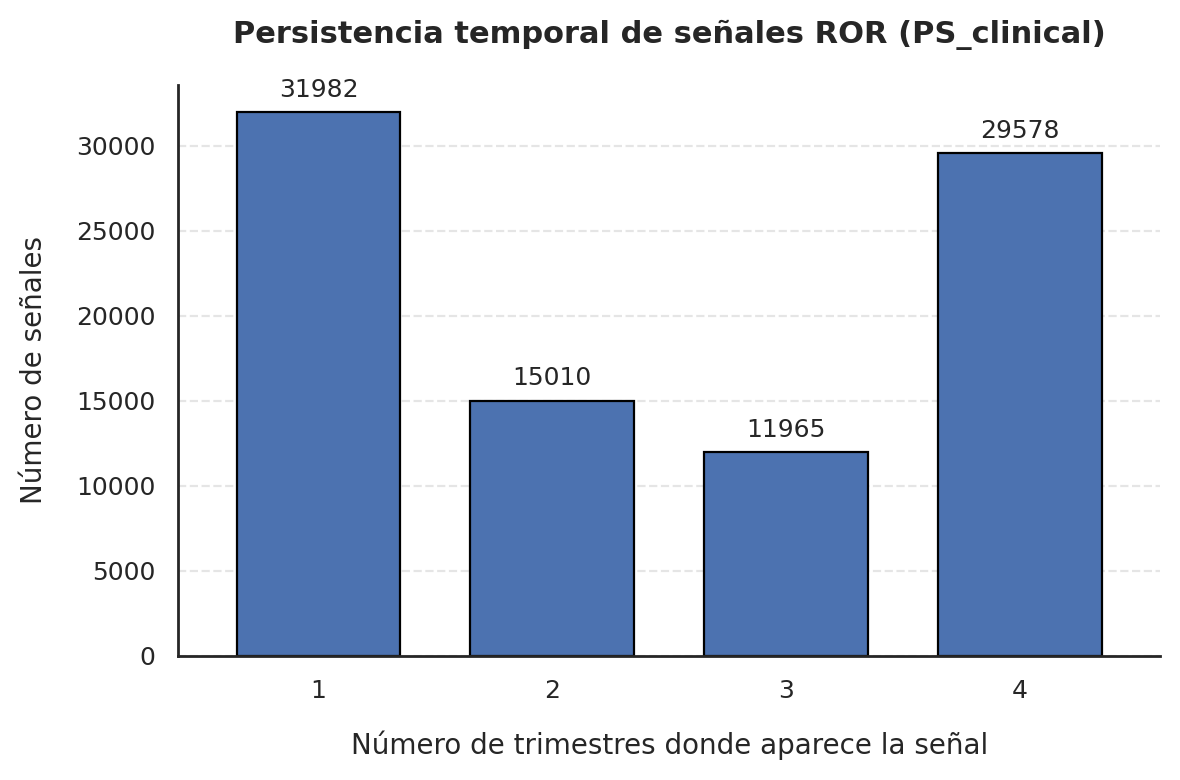

In [30]:
# Distribución de persistencia (1–4 trimestres) 
persist_counts = (presence_mat["n_quarters_present"] #toma la columna de persistencia
                  .value_counts() #cuenta frecuencias
                  .sort_index()) #ordena del 1 al 4

fig, ax = plt.subplots(figsize=(6, 4), dpi=200) 
bars = persist_counts.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="black", width=0.7)

ax.set_title(f"Persistencia temporal de señales ROR ({TIME_LABEL})", pad=15, fontweight="bold") 
ax.set_xlabel("Número de trimestres donde aparece la señal", labelpad=10)
ax.set_ylabel("Número de señales", labelpad=10) 

ax.grid(True, axis="y", linestyle="--", alpha=0.5) # Cuadrícula Y un poco más visible
ax.set_axisbelow(True) # Envía la cuadrícula detrás de las barras
ax.tick_params(axis="x", labelrotation=0) # Mantiene números del eje X derechitos (horizontales)


ax.spines["top"].set_visible(False) 
ax.spines["right"].set_visible(False)

# Ciclo para poner el valor numérico exacto encima de cada barra
for p in ax.patches: 
    ax.annotate(format(p.get_height(), '.0f'), #obtiene el valor de la barra sin decimales
                (p.get_x() + p.get_width() / 2., p.get_height()), #calcula el centro superior de la barra
                ha='center', va='center', 
                xytext=(0, 8), # Sube el texto 8 puntitos para que no toque 
                textcoords='offset points', 
                fontsize=9) 

plt.tight_layout() # Ajusta los márgenes 

out_fp = FIG_DIR / f"persistencia_barras_{TIME_LABEL}.png" # Define la ruta donde se guardará
plt.savefig(out_fp, dpi=300, bbox_inches="tight") 
plt.show() 

In [4]:
#Lo que observamos en esta grafica es que 31mil señales aparecieron unicamente en un trimestre, leugo ente 15mil y 11 mil en 2 o 3 trimestres y 29,578 aparecen en 4 trimestres lo que es sumamente preocupante 

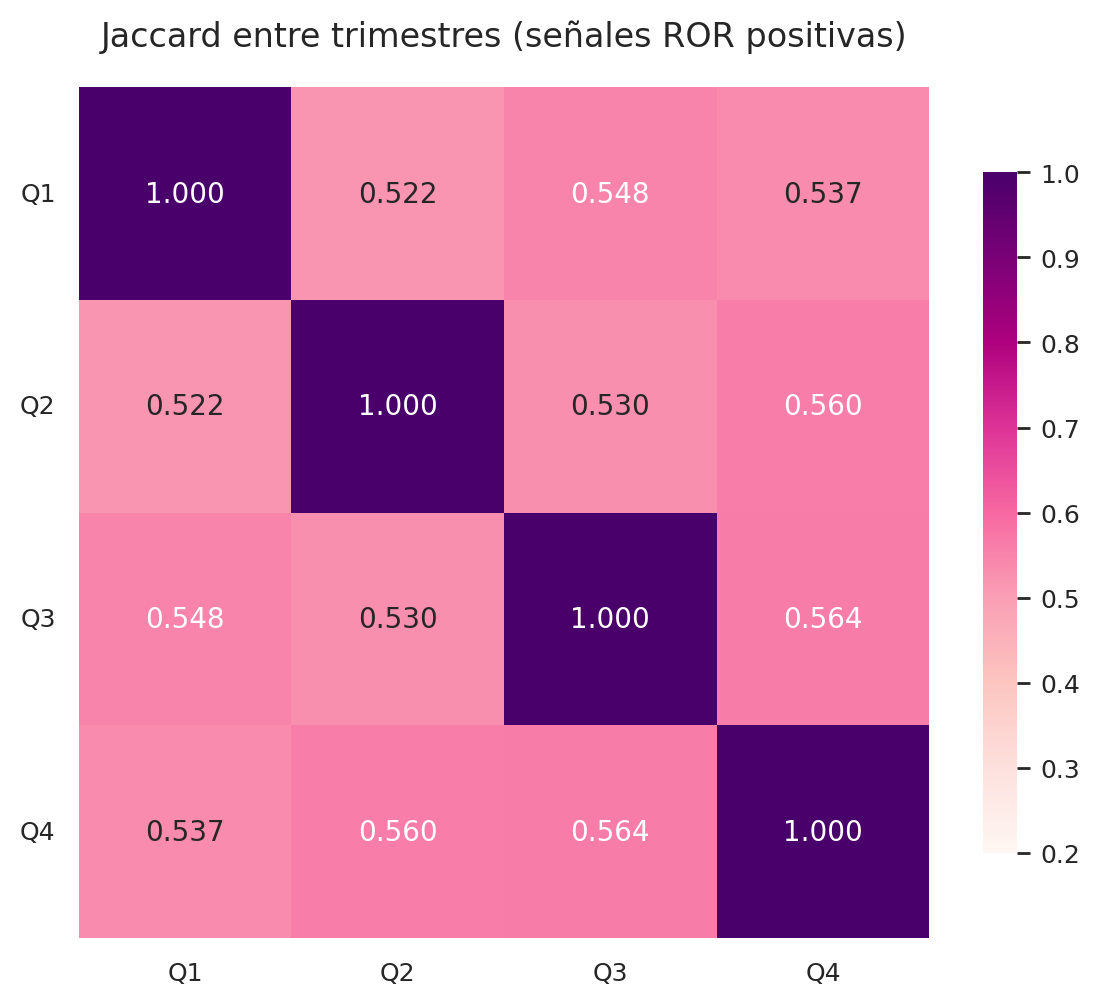

In [33]:
q_short = ["Q1", "Q2", "Q3", "Q4"] 

jaccard_plot = jaccard_mat.copy() 

jaccard_plot.index = q_short 
jaccard_plot.columns = q_short

fig, ax = plt.subplots(figsize=(6, 5), dpi=200) 

sns.heatmap( # Genera el mapa de calor
    jaccard_plot.astype(float), # Asegura datos numéricos
    annot=True, # Muestra los números adentro
    fmt=".3f", # Formato de 3 decimales
    ax=ax, 
    square=True, # Cuadros perfectos
    cmap="RdPu", 
    vmin=0.2, vmax=1.0, 
    cbar_kws={"shrink": .8} )

ax.set_title("Jaccard entre trimestres (señales ROR positivas)", pad=15, fontsize=12) 
ax.set_xlabel("") # Oculta etiqueta X
ax.set_ylabel("") 


ax.tick_params(axis="x", labelrotation=0) 
ax.tick_params(axis="y", labelrotation=0)

plt.tight_layout()
out_fp = FIG_DIR / f"heatmap_jaccard_global_{TIME_LABEL}.png" 
plt.savefig(out_fp, dpi=300, bbox_inches="tight") 
plt.show() 

In [5]:
#Q1 Y Q2 COMPARTEN UN 52% de seales , aqui tenemos una interseccion de señales, lo mismo se puede ver entre los demas trimestres 

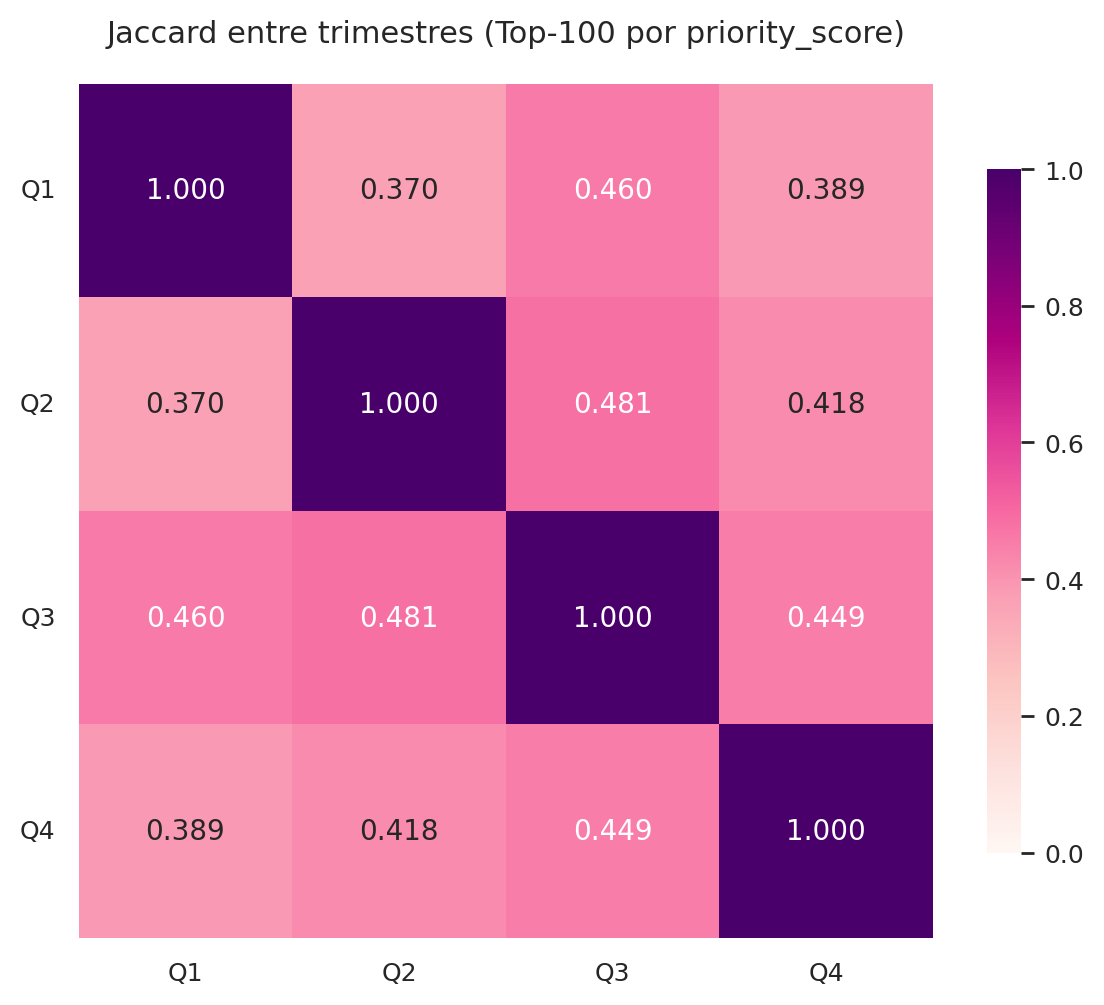

In [34]:
q_short = ["Q1", "Q2", "Q3", "Q4"] # Lista con los nombres cortos y limpios

jaccard_topk_plot = jaccard_topk.copy() # Copia la matriz del Top-K original

# Forzamos los nombres cortos directamente para evitar las rutas largas y encimadas
jaccard_topk_plot.index = q_short 
jaccard_topk_plot.columns = q_short

fig, ax = plt.subplots(figsize=(6, 5), dpi=200) # Tamaño ideal para que no se apriete nada

sns.heatmap( # Crea el mapa de calor
    jaccard_topk_plot.astype(float), # Asegura que los datos sean números
    annot=True, # Muestra los valores numéricos adentro de cada cuadro
    fmt=".3f", # Formato de 3 decimales
    ax=ax, 
    square=True, # Hace que los cuadros sean cuadritos perfectos
    cmap="RdPu", # Aplica los mismos colores degradados rosas y morados
    vmin=0.0, vmax=1.0, # El rango de similitud Jaccard va de 0 a 1
    cbar_kws={"shrink": .8} # Hace la barra lateral indicadora más estética
)

ax.set_title(f"Jaccard entre trimestres (Top-{TOPK} por priority_score)", pad=15, fontsize=11) # Título limpio y centrado
ax.set_xlabel("") # Oculta la etiqueta inferior del eje X
ax.set_ylabel("") # Oculta la etiqueta lateral del eje Y

# Mantiene las etiquetas de los trimestres (Q1, Q2...) completamente derechas
ax.tick_params(axis="x", labelrotation=0) 
ax.tick_params(axis="y", labelrotation=0)

plt.tight_layout() # Ajusta automáticamente los espacios para que nada se corte

out_fp = FIG_DIR / f"heatmap_jaccard_top{TOPK}_{TIME_LABEL}.png" # Define la ruta de guardado
plt.savefig(out_fp, dpi=300, bbox_inches="tight") # Guarda la imagen en alta calidad para la tesis
plt.show() # Muestra la gráfica final limpiecita

#En la tabla anterior podiamos ver toda la poblacion pero para esta grafica solo tomamos el top 100 por eso es que se ve una
disminucion en los numeros entre.370 a .481 por lo que podemos ver que comparten entre un 37-48 porciento , lo cual es altisimo en un top 100

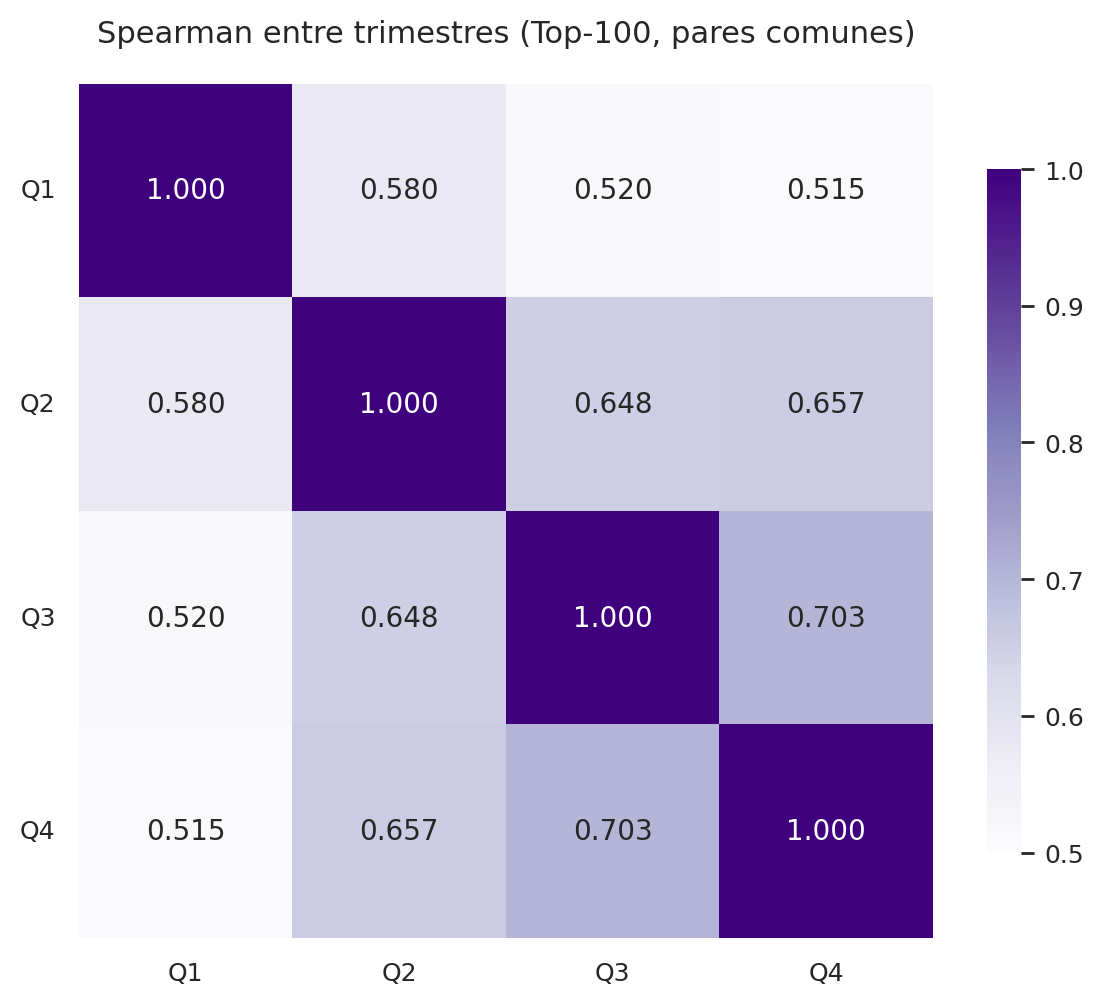

In [35]:
q_short = ["Q1", "Q2", "Q3", "Q4"] # Lista con los nombres cortos y limpios

spearman_plot = spearman_mat.copy() # Copia la matriz de Spearman original

# Forzamos los nombres cortos directamente para evitar textos largos y encimados
spearman_plot.index = q_short 
spearman_plot.columns = q_short

fig, ax = plt.subplots(figsize=(6, 5), dpi=200) # Tamaño ideal para que nada se apriete

sns.heatmap( # Crea el mapa de calor
    spearman_plot.astype(float), # Asegura que los datos sean números
    annot=True, # Muestra los valores numéricos adentro de los cuadros
    fmt=".3f", # Formato de 3 decimales
    ax=ax, 
    square=True, # Hace que los cuadros sean cuadritos perfectos
    cmap="Purples", # CAMBIO: Aplica un degradado en tonos violeta/morado
    vmin=0.5, vmax=1.0, # El rango lógico para tus datos de correlación
    cbar_kws={"shrink": .8} # Hace la barra indicadora lateral más estética
)

ax.set_title(f"Spearman entre trimestres (Top-{TOPK}, pares comunes)", pad=15, fontsize=11) # Título limpio y con buen espacio
ax.set_xlabel("") # Oculta la etiqueta inferior del eje X
ax.set_ylabel("") # Oculta la etiqueta lateral del eje Y

# Mantiene las etiquetas de los trimestres completamente derechas
ax.tick_params(axis="x", labelrotation=0) 
ax.tick_params(axis="y", labelrotation=0)

plt.tight_layout() # Ajusta automáticamente los espacios para que no se corte la imagen

out_fp = FIG_DIR / f"heatmap_spearman_top{TOPK}_{TIME_LABEL}.png" # Define la ruta de guardado
plt.savefig(out_fp, dpi=300, bbox_inches="tight") # Guarda la gráfica en alta resolución
plt.show() # Muestra la gráfica final limpiecita

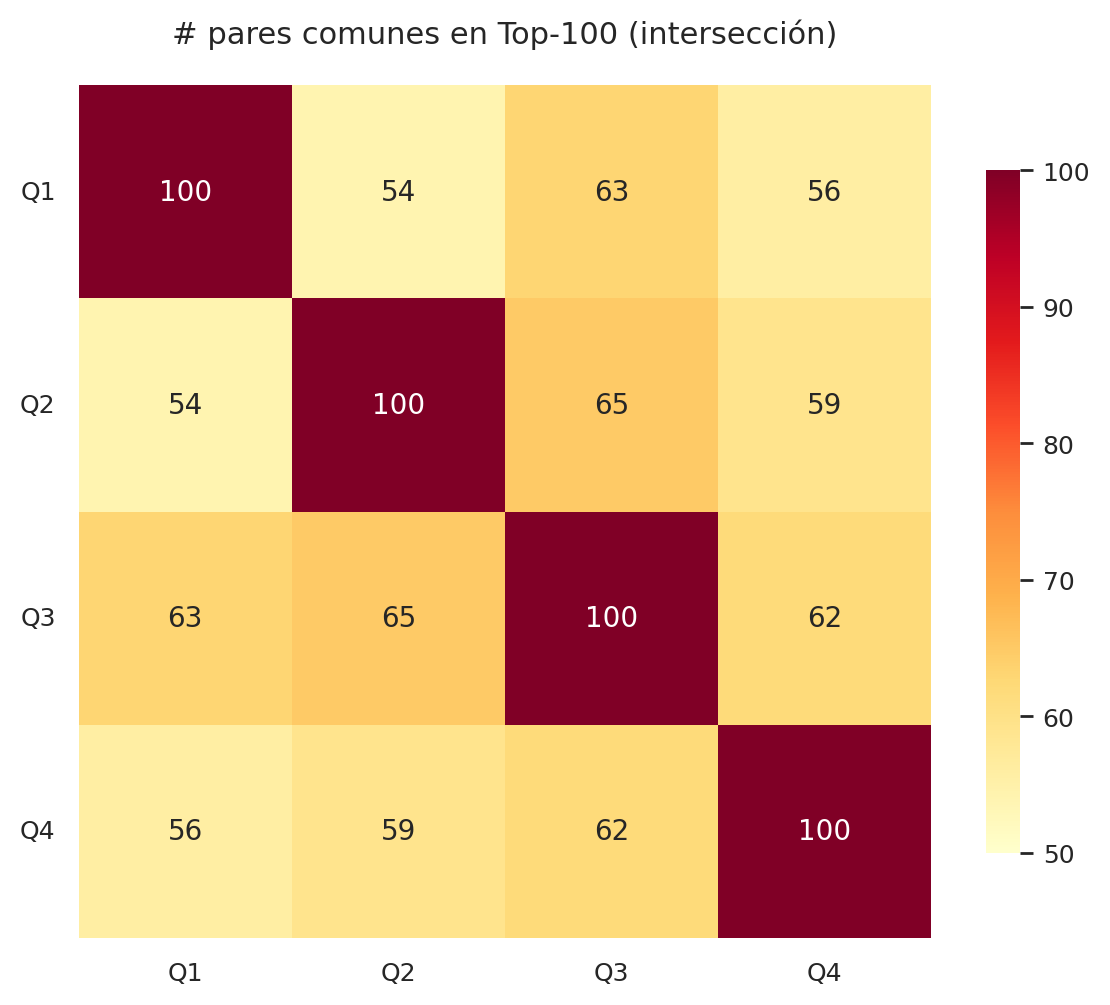

In [36]:
q_short = ["Q1", "Q2", "Q3", "Q4"] # Lista con los nombres cortos y limpios

n_common_plot = n_common_mat.copy() # Copia la matriz de pares comunes

# Forzamos los nombres cortos directamente para evitar textos encimados
n_common_plot.index = q_short 
n_common_plot.columns = q_short

fig, ax = plt.subplots(figsize=(6, 5), dpi=200) # Tamaño ideal para la figura

sns.heatmap( # Genera el mapa de calor
    n_common_plot.astype(float), # Asegura que los datos sean números
    annot=True, # Muestra los números de pares comunes
    fmt=".0f", # Formato sin decimales (son conteos enteros)
    ax=ax, 
    square=True, # Cuadros perfectos
    cmap="YlOrRd", # CAMBIO: Degradado de amarillo, naranja y rojo vivo
    vmin=50, vmax=100, # Rango de color basado en tus datos (Top-100)
    cbar_kws={"shrink": .8} # Estiliza la barra lateral
)

ax.set_title(f"# pares comunes en Top-{TOPK} (intersección)", pad=15, fontsize=11) # Título centrado
ax.set_xlabel("") # Quita etiqueta X
ax.set_ylabel("") # Quita etiqueta Y

# Mantiene las etiquetas Q1-Q4 totalmente horizontales
ax.tick_params(axis="x", labelrotation=0) 
ax.tick_params(axis="y", labelrotation=0)

plt.tight_layout() # Ajusta márgenes para evitar cortes

out_fp = FIG_DIR / f"heatmap_n_common_top{TOPK}_{TIME_LABEL}.png" # Ruta de guardado
plt.savefig(out_fp, dpi=300, bbox_inches="tight") # Guarda en alta calidad
plt.show() # Muestra la gráfica vibrante

In [6]:
#Lo que vemos con spearman es que la concentracion es altisima, todas las señales son fuertes y no fluctuan de forma aleatoria